In [1]:
from net2brain.feature_extraction import FeatureExtractor
from net2brain.utils.download_datasets import DatasetBonnerPNAS2017

paths = DatasetBonnerPNAS2017.load_dataset()
stimuli_path = paths["stimuli_path"]

fx = FeatureExtractor(model='AlexNet', netset='Standard', device='cpu')
fx.extract(data_path=stimuli_path, save_path='AlexNet_feat')
fx.consolidate_per_layer()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Processing files: 100%|██████████| 50/50 [00:00<00:00, 87.48it/s, subfiles=1/1]


Consolidating data per layer...


100%|██████████| 50/50 [00:00<00:00, 311.74it/s]


No files to consolidate.


CREATING RDMs
After feature extraction, the next step is to create Representational Dissimilarity Matrices (RDMs) using Net2Brain's RDM Creator.

In [2]:
from net2brain.rdm_creation import RDMCreator

feat_path = "AlexNet_feat"
save_path = "AlexNet_RDM"

creator = RDMCreator(verbose=True, device='cpu')
save_path = creator.create_rdms(feature_path=feat_path, save_path=save_path, save_format='npz')


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/net2brain/rdm/feature_iterator.py:388: UserWarning: Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, and will have no effect for the provided format FeatureFormat.NPZ_CONSOLIDATED.
  warnings.warn(f"Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, "
Creating RDMs: 100%|██████████| 21/21 [00:00<00:00, 58.80it/s]


In this example, the RDMCreator class is used to create RDMs from previously extracted features using the AlexNet model. The extracted features are located at feat_path, and the resulting RDMs will be saved at save_path.

The RDM Creator calculates dissimilarities between neural representations of different images and generates RDMs with a shape of (#Images, #Images) for each specified layer. These RDMs provide insights into the similarities and differences in neural representations.

One of the key evaluation metrics available is RSA (Representational Similarity Analysis)

In [5]:
from net2brain.feature_extraction import FeatureExtractor
from net2brain.evaluations.rsa import RSA
from net2brain.utils.download_datasets import DatasetBonnerPNAS2017
from net2brain.rdm_creation import RDMCreator

paths = DatasetBonnerPNAS2017.load_dataset()
stimuli_path = paths["stimuli_path"]
roi_path = paths["roi_path"]

fx = FeatureExtractor(model='AlexNet', netset='Standard', device='cpu')
fx.extract(data_path=stimuli_path, save_path='AlexNet_feat')
fx.consolidate_per_layer()

creator = RDMCreator(device='cpu')
creator.create_rdms(feature_path='AlexNet_feat', save_path='AlexNet_RDM', save_format='npz')

evaluation_alexnet = RSA("AlexNet_RDM", roi_path, model_name="AlexNet")
dataframe1 = evaluation_alexnet.evaluate()
display(dataframe1)

Processing files: 100%|██████████| 50/50 [00:00<00:00, 93.46it/s, subfiles=1/1]


Consolidating data per layer...


100%|██████████| 50/50 [00:00<00:00, 385.36it/s]


No files to consolidate.


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/net2brain/rdm/feature_iterator.py:388: UserWarning: Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, and will have no effect for the provided format FeatureFormat.NPZ_CONSOLIDATED.
  warnings.warn(f"Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, "


,ROI,Layer,Model,R2,%R2,R2_array,Significance,SEM,LNC,UNC
0,(0) fmri_PHC1,(0) RDM_avgpool.npz,AlexNet,0.007849,20.580979,"[0.014685507397069798, 0.0014048720131622644, ...",0.000021,0.001291,0.038140,0.119031
1,(0) fmri_PHC1,(1) RDM_classifier_0.npz,AlexNet,0.007849,20.580979,"[0.014685507397069798, 0.0014048720131622644, ...",0.000021,0.001291,0.038140,0.119031
2,(0) fmri_PHC1,(2) RDM_classifier_1.npz,AlexNet,0.012424,32.576000,"[0.016532943905281393, 0.0008148571101386892, ...",0.000157,0.002483,0.038140,0.119031
3,(0) fmri_PHC1,(3) RDM_classifier_2.npz,AlexNet,0.012424,32.576000,"[0.016532943905281393, 0.0008148571101386892, ...",0.000157,0.002483,0.038140,0.119031
4,(0) fmri_PHC1,(4) RDM_classifier_3.npz,AlexNet,0.012424,32.576000,"[0.016532943905281393, 0.0008148571101386892, ...",0.000157,0.002483,0.038140,0.119031
...,...,...,...,...,...,...,...,...,...,...
310,(14) fmri_VO2,(16) RDM_features_8.npz,AlexNet,0.012181,30.293792,"[0.00749134719470036, 0.001204036143079018, 0....",0.000147,0.002418,0.040208,0.121685
311,(14) fmri_VO2,(17) RDM_features_9.npz,AlexNet,0.012181,30.293792,"[0.00749134719470036, 0.001204036143079018, 0....",0.000147,0.002418,0.040208,0.121685
312,(14) fmri_VO2,(18) RDM_features_10.npz,AlexNet,0.008240,20.493893,"[0.005332383850526719, 0.0018695398797197984, ...",0.000237,0.001719,0.040208,0.121685
313,(14) fmri_VO2,(19) RDM_features_11.npz,AlexNet,0.008240,20.493893,"[0.005332383850526719, 0.0018695398797197984, ...",0.000237,0.001719,0.040208,0.121685


PLOTTING RSA EVALUATION RESULTS

The integrated plotting functionality of Net2Brain allows you to easily visualize the RSA evaluation results.

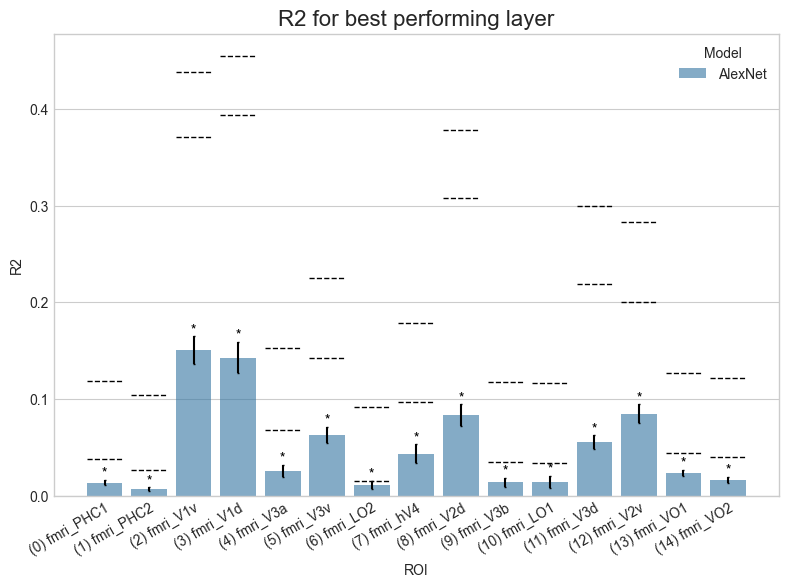

In [6]:
from net2brain.evaluations.plotting import Plotting

plotter = Plotting([dataframe1])
results = plotter.plot()